# Guardian Coverage of Ethiopia (1996–2021)
### Does international media portrayal correlate with tourist arrivals?

---

> **Before running this notebook, please read the `README.md` file first.**
> It explains how to set up the project, fetch the data, and run the full pipeline.
> This notebook assumes `data/ethiopia_analysis.csv` already exists.
> If it does not, follow the pipeline steps in the README or clone the repo I have submitted on the classroom(https://github.com/senagal/SenaAbdisa_Ethiopia_FinalProject).

> If possible, it is better if you use the deployed streamlit app instead of reading this notebook since it is easier to follow (https://senaaethiopiafinalproject-b3dbvtphkarquw8dxhtw7c.streamlit.app/) or run it locally `streamlit run streamlit.py`.

> This code does only the analysis, for the data fetching, cleaning etc read the pipeline on the README.md

---

## Project Overview

This project started from a simple question: *"How is Ethiopia being portrayed in international media, and can we see correlation of the number of articles and the number of tourists we get?" It is basically the initial step to creating a tool that can analyse the if the narrative of a country on the internet affects its tourism industry.*

The analysis focuses on **The Guardian** newspaper (1996–2021), using their official API to collect articles mentioning Ethiopia. Article sentiment and topics were labelled using GPT-5-mini. Tourist arrival data was sourced from Kaggle.

**Six research questions are explored:**

1. How has the quantity of The Guardian's coverage of Ethiopia changed over time?
2. How has the sentiment of their articles on Ethiopia changed over time?
3. Which topics dominate Ethiopia-related coverage?
4. Do years with more/less focused coverage correlate with higher or lower tourist arrivals the following year?
5. Do years with more/less negative coverage correspond to lower tourism the following year?
6. Do years with more/less positive coverage correspond to higher or lower tourism the following year?


## Setup
Import libraries and load the data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.formula.api import ols

# Display plots inline
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


In [3]:
# Load the prepared analysis data (one row per year)
df = pd.read_csv("data/ethiopia_analysis.csv")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

numeric_cols = [
    "total_articles", "focused_articles", "focus_rate",
    "average_sentiment_score",
    "positive_rate", "negative_rate", "neutral_rate",
    "positive_articles", "negative_articles", "neutral_articles",
    "tourist_arrivals", "tourist_arrivals_next_year",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

topic_count_cols = [c for c in df.columns if c.endswith("_count")]
topic_rate_cols = [
    c for c in df.columns
    if c.endswith("_rate") and c not in {
        "focus_rate", "positive_rate", "negative_rate",
        "neutral_rate", "tourism_growth_rate", "tourism_growth_rate_next_year",
    }
]

df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)
df = df.sort_values("year").reset_index(drop=True)

print(f"Loaded {len(df)} years of data ({df['year'].min()} to {df['year'].max()})")
df.head()


Loaded 26 years of data (1996 to 2021)


,year,total_articles,focused_articles,average_sentiment_score,positive_articles,neutral_articles,negative_articles,focus_rate,positive_rate,neutral_rate,...,conflict_and_security_rate,economy_and_business_rate,environment_and_climate_rate,health_and_development_rate,other_rate,politics_and_governance_rate,sport_and_football_rate,tourism_and_culture_rate,tourist_arrivals,tourist_arrivals_next_year
0,1996,1,0,0.000000,0,1,0,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,108000.0,115000.0
1,1997,2,0,0.000000,0,2,0,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,115000.0,91000.0
2,1998,7,1,-0.142857,1,4,2,0.142857,0.142857,0.571429,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,91000.0,92000.0
3,1999,129,25,-0.155039,6,97,26,0.193798,0.046512,0.751938,...,0.640000,0.000000,0.000000,0.240000,0.080000,0.000000,0.0,0.040000,92000.0,109000.0
4,2000,203,38,-0.162562,12,146,45,0.187192,0.059113,0.719212,...,0.473684,0.052632,0.026316,0.236842,0.026316,0.078947,0.0,0.105263,109000.0,116000.0


### Helper: Linear Regression Plot
This function is used throughout the notebook to fit and visualise a simple linear regression, one data point per year.

In [4]:
def regression_plot(x, y, x_label, y_label, title, year_labels=None):
    """Fits y = m*x + k, plots data, fitted line, residuals, and year labels."""
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = np.array(x)[mask], np.array(y)[mask]
    if year_labels is not None:
        year_labels = np.array(year_labels)[mask]

    if len(x) < 3:
        print("Not enough data points.")
        return

    m, k  = np.polyfit(x, y, 1)
    model = ols("y ~ x", data=pd.DataFrame({"x": x, "y": y})).fit()
    r2    = model.rsquared
    pval  = model.pvalues["x"]

    predicted = m * x + k
    y_range   = y.max() - y.min() if y.max() != y.min() else 1

    fig, ax = plt.subplots(figsize=(10, 4))

    for xi, yi, pi in zip(x, y, predicted):
        ax.plot([xi, xi], [yi, pi], linestyle=":", color="gray", linewidth=0.8, zorder=1)

    ax.scatter(x, y, color="#1A6B5A", s=60, zorder=3)

    if year_labels is not None:
        for xi, yi, yr in zip(x, y, year_labels):
            ax.text(xi, yi + y_range * 0.025, str(int(yr)),
                    fontsize=7, ha="center", alpha=0.85)

    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + k, color="black", linewidth=1.5, zorder=2)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    direction = "positive" if m > 0 else "negative"
    sig = "statistically significant (p < 0.05)" if pval < 0.05 else "NOT statistically significant (p >= 0.05)"
    print(f"Slope m = {m:.4f}  |  R² = {r2:.3f}  |  p-value = {pval:.4f}")
    print(f"Direction: {direction}  |  {sig}")
    return {"slope": m, "r_squared": r2, "p_value": pval}


---
## Q1. How has Guardian coverage of Ethiopia changed over time?

Each bar shows the total articles mentioning Ethiopia that year, split into:
- **Focused** (dark teal): Ethiopia is the primary subject of the article
- **Mention only** (light grey): Ethiopia is referenced briefly in passing

A focused article carries more weight for our analysis since it reflects deliberate, sustained attention to Ethiopia rather than a passing reference.


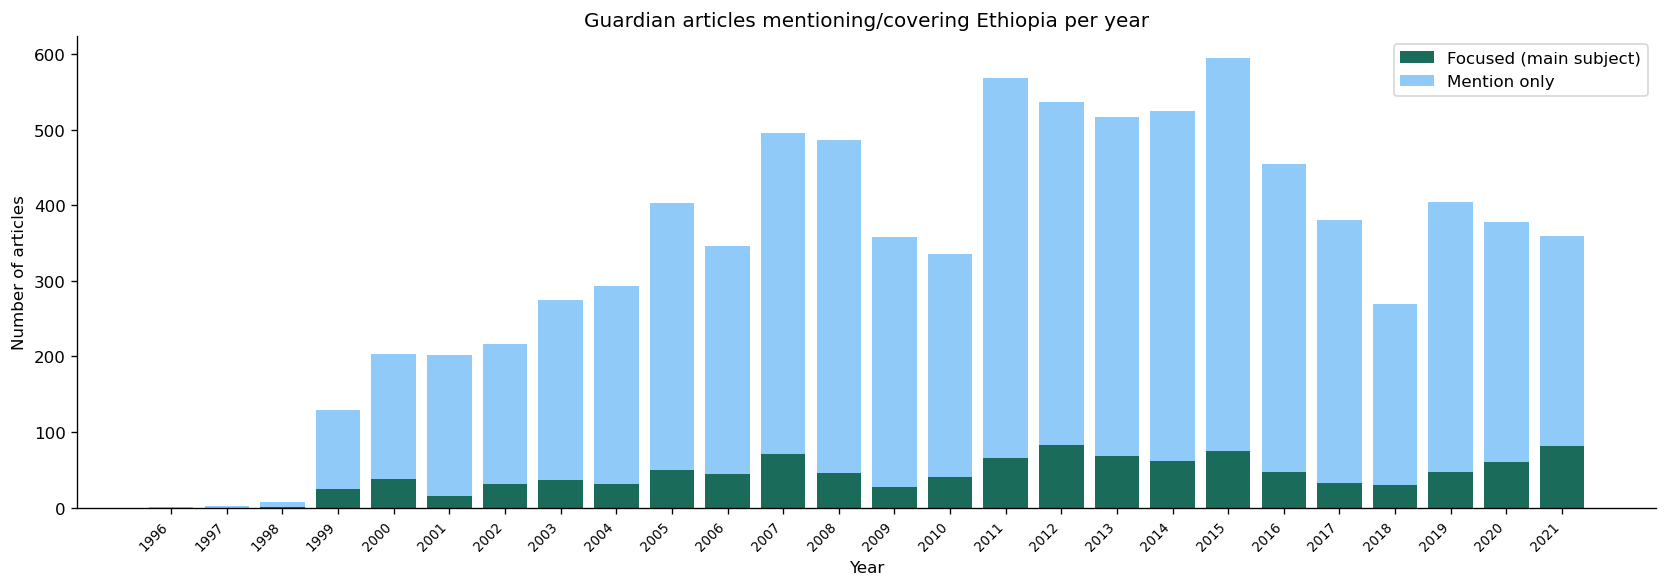

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

mention_only = (df["total_articles"] - df["focused_articles"]).clip(lower=0)

ax.bar(df["year"], df["focused_articles"], color="#1A6B5A", label="Focused (main subject)")
ax.bar(df["year"], mention_only, bottom=df["focused_articles"], color="#90CAF9", label="Mention only")

ax.set_title("Guardian articles mentioning/covering Ethiopia per year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of articles")
ax.set_xticks(df["year"])
ax.set_xticklabels(df["year"], rotation=45, ha="right", fontsize=8)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Coverage trend: focused articles over time

In [ ]:
regression_plot(
    x=df["year"], y=df["focused_articles"],
    x_label="Year", y_label="Focused articles",
    title="Focused Guardian coverage of Ethiopia over time",
    year_labels=df["year"],
)


### Coverage trend: total articles over time

In [ ]:
regression_plot(
    x=df["year"], y=df["total_articles"],
    x_label="Year", y_label="Total articles",
    title="Total Guardian coverage of Ethiopia over time",
    year_labels=df["year"],
)


### Q1 Findings

Both focused and total coverage show a **statistically significant upward trend** over time with p < 0.05, meaning it is statistically significant.

- Total articles grow by roughly **16 per year** on average (m ~16), meaning Ethiopia is increasingly mentioned across The Guardian's output.
- Focused articles grow by roughly **2 per year** (m ~2), meaning articles where Ethiopia is the primary subject are also increasing, though more gradually.

Notable spikes visible in the bar chart corresponds with major events like the 2007/2008 food crisis, the 2011 East Africa famine, and the 2015 refugee and political crisis years, meaning that the coverage was likely on them. The dip around 2018 and recovery toward 2020/2021 likely reflects the Tigray conflict beginning to dominate coverage.

The overall observation is that **The Guardian's coverage of Ethiopia has grown consistently over the 25-year period studied.**


---
## Q2. How has sentiment of articles on Ethiopia changed over time?

Each article was labelled by GPT-5-mini as **Positive**, **Neutral**, or **Negative** based on how Ethiopia is portrayed overall.

The **average sentiment score** is calculated as the sum of the sentiment value for each article that year divided by the number of articles. Sentiment value given is: Positive = +1, Neutral = 0, Negative = -1. A score above zero means more positive than negative articles in that year; below zero means the opposite.


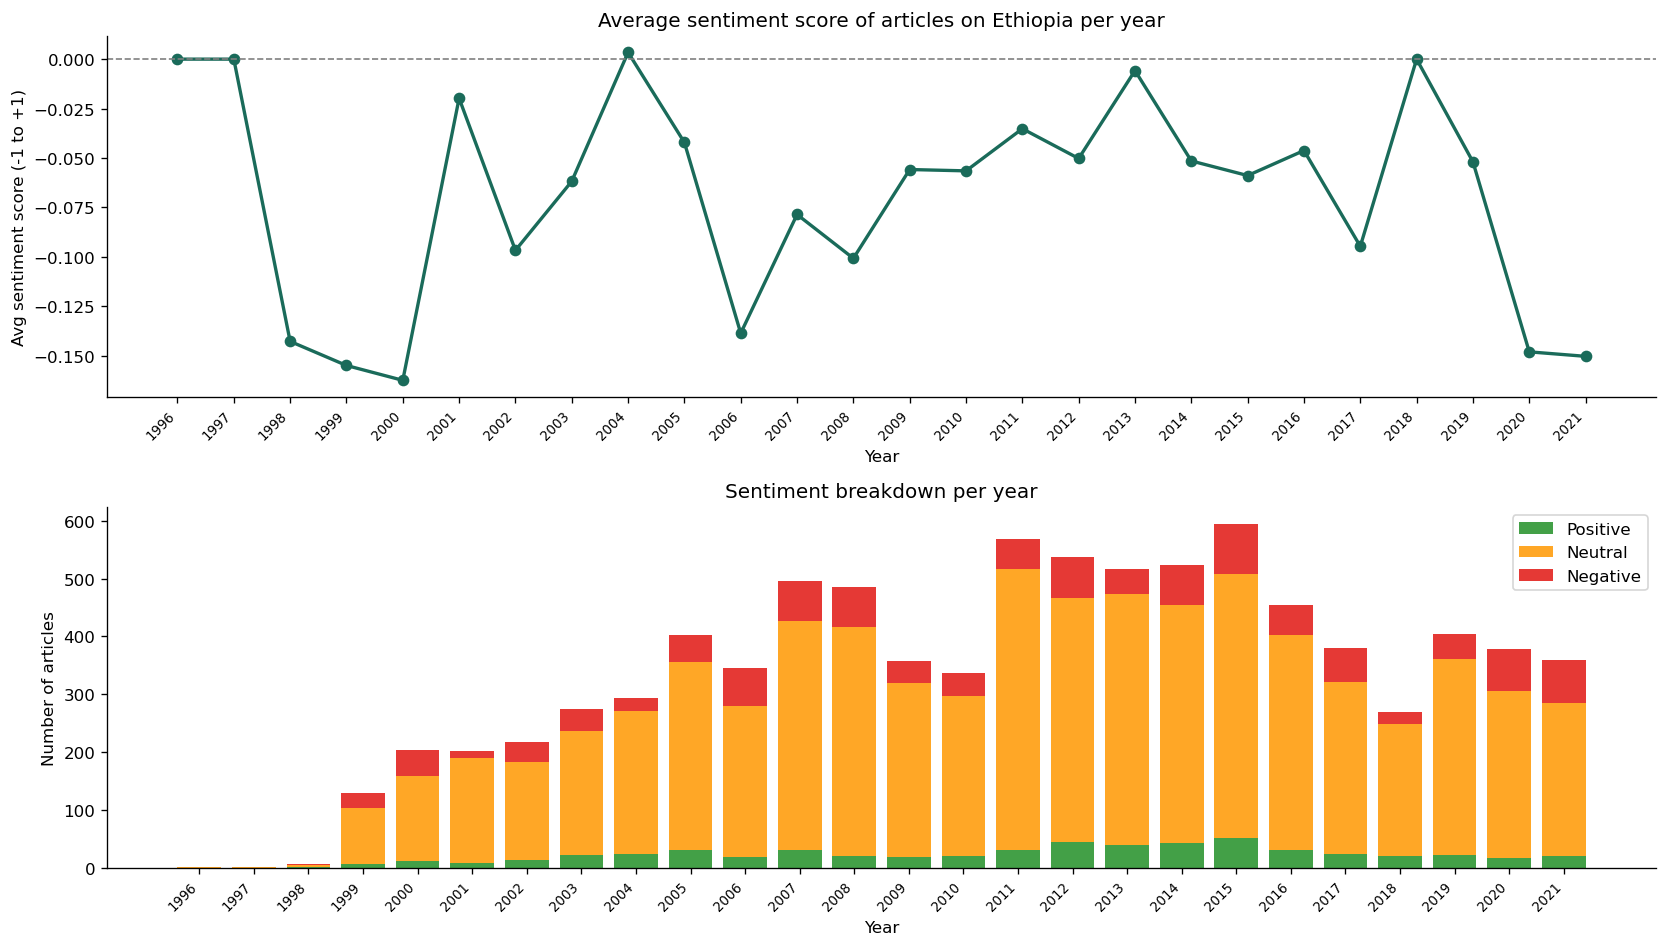

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: average sentiment score line
ax = axes[0]
ax.plot(df["year"], df["average_sentiment_score"], color="#1A6B5A", linewidth=2, marker="o", markersize=6)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Average sentiment score of articles on Ethiopia per year")
ax.set_xlabel("Year")
ax.set_ylabel("Avg sentiment score (-1 to +1)")
ax.set_xticks(df["year"])
ax.set_xticklabels(df["year"], rotation=45, ha="right", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Plot 2: stacked bar of positive/neutral/negative counts
ax2 = axes[1]
ax2.bar(df["year"], df["positive_articles"].fillna(0), color="#43A047", label="Positive")
ax2.bar(df["year"], df["neutral_articles"].fillna(0),
        bottom=df["positive_articles"].fillna(0), color="#FFA726", label="Neutral")
ax2.bar(df["year"], df["negative_articles"].fillna(0),
        bottom=(df["positive_articles"].fillna(0) + df["neutral_articles"].fillna(0)),
        color="#E53935", label="Negative")
ax2.set_title("Sentiment breakdown per year")
ax2.set_xlabel("Year")
ax2.set_ylabel("Number of articles")
ax2.set_xticks(df["year"])
ax2.set_xticklabels(df["year"], rotation=45, ha="right", fontsize=8)
ax2.legend()
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


### Sentiment trend: has it changed over time?

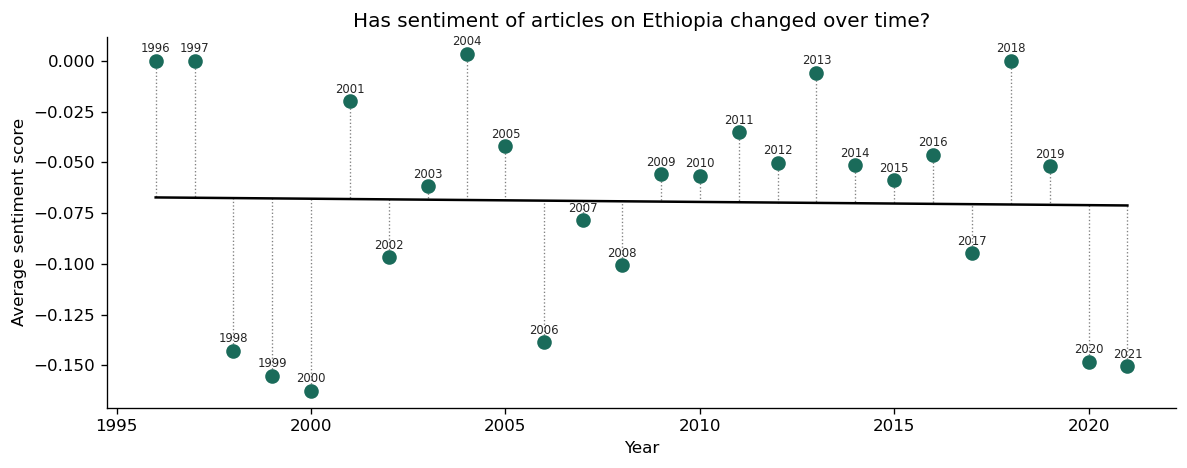

Slope m = -0.0002  |  R² = 0.001  |  p-value = 0.9127
Direction: negative  |  NOT statistically significant (p >= 0.05)


{'slope': np.float64(-0.00015830094696486443),
 'r_squared': np.float64(0.0005115088243243804),
 'p_value': np.float64(0.9126756009261067)}

In [7]:
regression_plot(
    x=df["year"], y=df["average_sentiment_score"],
    x_label="Year", y_label="Average sentiment score",
    title="Has sentiment of articles on Ethiopia changed over time?",
    year_labels=df["year"],
)


In [8]:
# Key stats
most_pos = df.loc[df["average_sentiment_score"].idxmax()]
most_neg = df.loc[df["average_sentiment_score"].idxmin()]
overall  = df["average_sentiment_score"].mean()

print(f"Most positive year : {int(most_pos['year'])}  (score {most_pos['average_sentiment_score']:.3f})")
print(f"Most negative year : {int(most_neg['year'])}  (score {most_neg['average_sentiment_score']:.3f})")
print(f"Overall average    : {overall:.3f}")


Most positive year : 2004  (score 0.003)
Most negative year : 2000  (score -0.163)
Overall average    : -0.069


### Q2 Findings

The regression slope is nearly flat and the p-value is well above 0.05, meaning the trend is **not statistically significant**. We cannot conclude that sentiment of articles on Ethiopia in The Guardian has meaningfully changed over the 25 years studied.

The average sentiment score consistently sits **below zero**, meaning negative articles outnumber positive ones in most years. However, looking at the stacked bar chart, **neutral articles make up the largest share** of coverage in almost every year. The negative lean in the score is driven by a modest but persistent gap between negative and positive articles, not by an overwhelming volume of negative coverage.

In short: coverage has grown, but its tone has remained consistently and mildly negative throughout the period, with no clear trend of improvement or deterioration.


---
## Q3. Which topics dominate Ethiopia-related coverage?

Topics are counted from **focused articles only** (where Ethiopia is the main subject). The topic rate for a given year is the number of articles on a topic divided by the total focused articles that year.

Topics were assigned by GPT-5-mini from the following categories: Politics & Governance, Economy & Business, Sport & Football, Tourism & Culture, Health & Development, Conflict & Security, Environment & Climate, or Other.


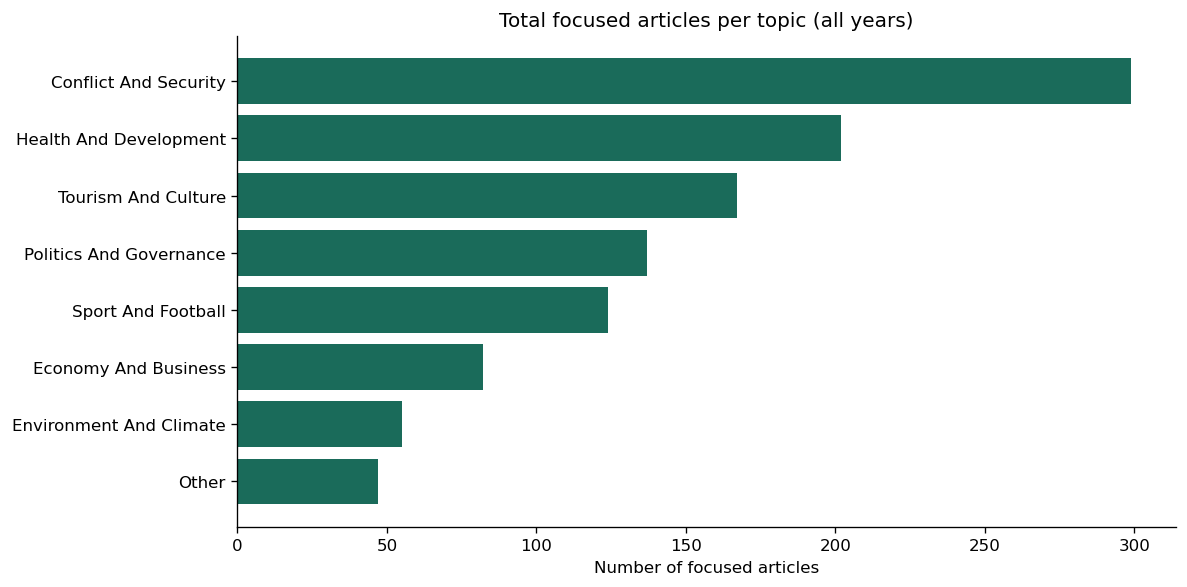

In [9]:
def pretty_topic(col, suffix="_count"):
    return col.replace(suffix, "").replace("_", " ").title()

# Overall totals across all years
topic_totals = df[topic_count_cols].sum().reset_index()
topic_totals.columns = ["topic", "count"]
topic_totals["topic"] = topic_totals["topic"].apply(pretty_topic)
topic_totals = topic_totals.sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(topic_totals["topic"], topic_totals["count"], color="#1A6B5A")
ax.set_title("Total focused articles per topic (all years)")
ax.set_xlabel("Number of focused articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Topic heatmap: how topic dominance shifts year by year

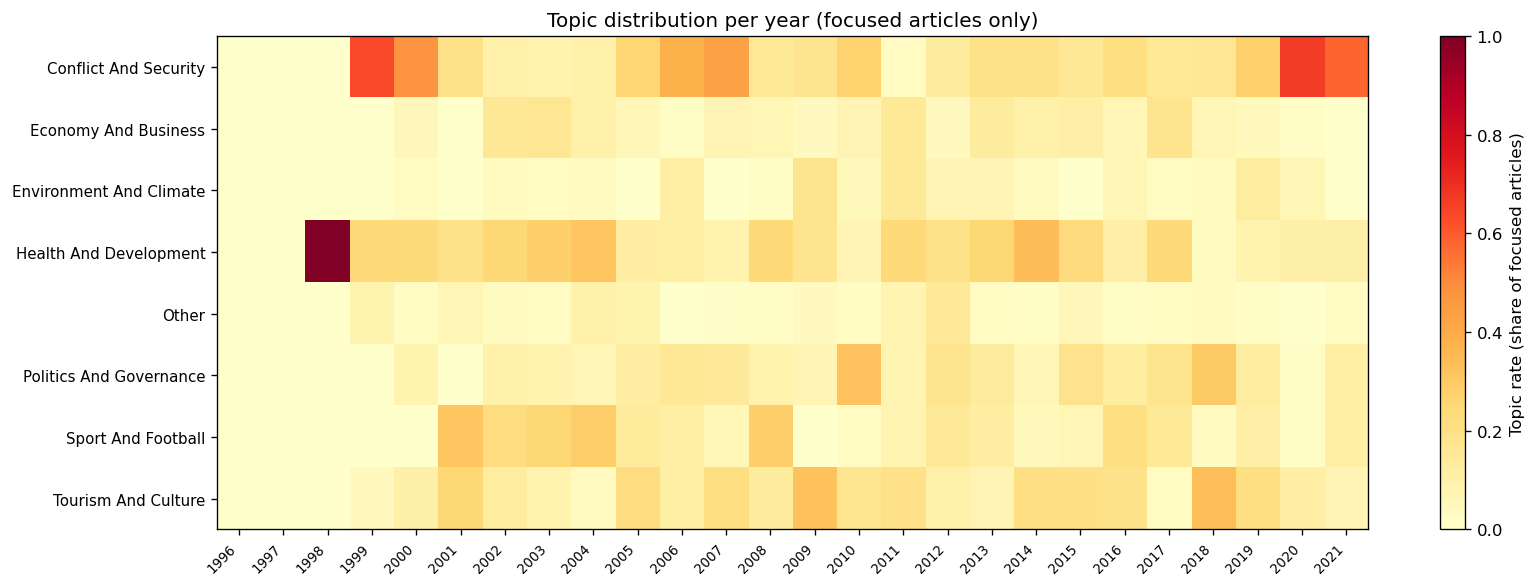

In [10]:
heatmap_data = df.set_index("year")[topic_rate_cols].T
heatmap_data.index = [pretty_topic(c, "_rate") for c in heatmap_data.index]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data.values.astype(float),
               aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
plt.colorbar(im, ax=ax, label="Topic rate (share of focused articles)")
ax.set_title("Topic distribution per year (focused articles only)")
plt.tight_layout()
plt.show()


### Q3 Findings

**Politics & Governance** and **Conflict & Security** consistently dominate focused coverage, which is unsurprising given Ethiopia's complex political history. Some examples include the 2005 elections, the Tigray conflict from 2020, and various regional tensions.

**Health & Development** then follows with **Sport & Football** coming next, which mostly becomes more visible as Ethiopian athletics, particularly long-distance running, gained international recognition.

**Tourism & Culture** remains a small but persistent category, which is relevant to our later questions about whether coverage correlates with tourist arrivals.

Use the heatmap to see which category dominated the topic rate for that year.


---
## Q4. Does focused coverage correlate with tourist arrivals the following year?

Finally for the major question, "Does number of articles correlate with number of tourist arrivals?" we will plot number of articles(focused/total) versus number of tourist arrivals and do a linear regression. Considering that most people do not visit a country right after they read about it, rather they take time to explore further before doing we will be using a one year lag so coverage in year t is compared with tourism in year t+1.

Each data point represents one year. The fitted line and statistics tell us whether the relationship is positive, negative, or flat.


In [ ]:
# Tourist arrivals over time - context
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["year"], df["tourist_arrivals"], color="#E65100", linewidth=2, marker="o", markersize=6)
ax.set_title("Ethiopia international tourist arrivals (1996-2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Tourist arrivals")
ax.set_xticks(df["year"])
ax.set_xticklabels(df["year"], rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Focused articles (year t) vs tourist arrivals (year t+1)

In [ ]:
regression_plot(
    x=df["focused_articles"],
    y=df["tourist_arrivals_next_year"],
    x_label="Focused articles (year t)",
    y_label="Tourist arrivals (year t+1)",
    title="Does focused coverage predict next-year tourism?",
    year_labels=df["year"],
)


### Total articles (year t) vs tourist arrivals (year t+1)

In [ ]:
regression_plot(
    x=df["total_articles"],
    y=df["tourist_arrivals_next_year"],
    x_label="Total articles (year t)",
    y_label="Tourist arrivals (year t+1)",
    title="Does total coverage predict next-year tourism?",
    year_labels=df["year"],
)


### Q4 Findings

For the regression results using focused articles vs number of tourist arrivals, we have a slope of roughly 7859 with a p-value of 0.0011 which means that for an increase of 1 article focusing on Ethiopia, we see an increase of about 7859 tourist arrivals the following year. And since the p-value is less than 0.05, this positive association is statistically significant, meaning it's unlikely to be due to random chance. Same goes for total articles, we have a slope of roughly 1233 with a p-value well less than 0.05 which means that for an increase of 1 article mentioning Ethiopia, we see an increase of about 1233 tourist arrivals the following year. 

>But does this mean that the more they write about us, the more tourists we get? **Not necessarily**. We can only say that there is a positive association between the two, but we cannot conclude causation from this analysis alone. There could be other factors at play, such as global events, economic conditions, or changes in travel trends that influence both media coverage and tourism independently. Also our source of articles is only The Guardian, which does not fully represent global media coverage. So while the association is interesting and suggests a potential link, we would need more comprehensive data and analysis to draw stronger conclusions about causality. This is just a starting point for a project I have wanted to do for a while, and scaling it up to cover more articles from different sources and more factors would be a great next step to explore these relationships further.


---
## Q5. Does more negative coverage correspond to lower tourism the following year?

If negative coverage deters tourists, we would expect a **negative slope**: higher negative rates in year *t* followed by fewer arrivals in year *t+1*.

We test both the negative rate (proportion of negative articles) and the raw count of negative articles.


### Negative rate (year t) vs tourist arrivals (year t+1)

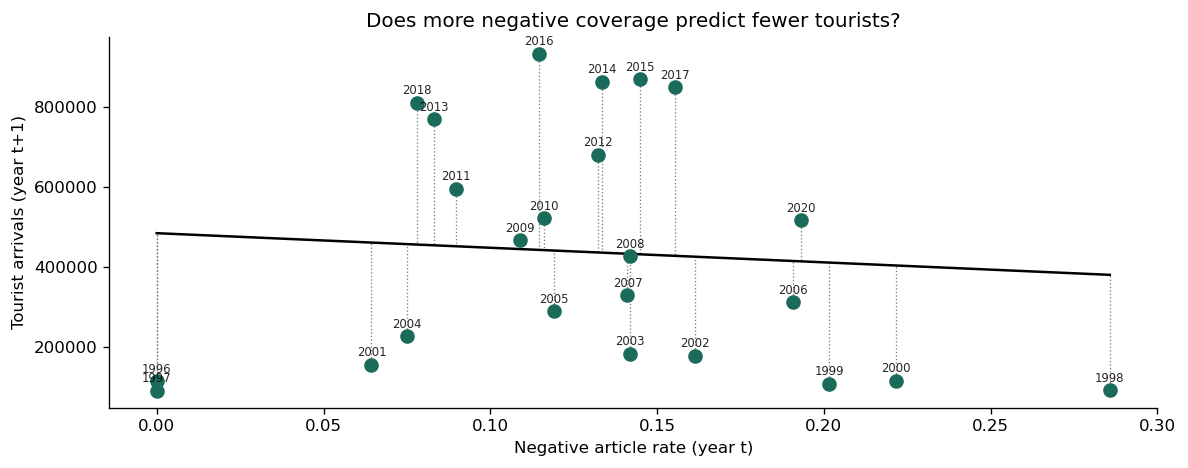

Slope m = -364512.1057  |  R² = 0.006  |  p-value = 0.7098
Direction: negative  |  NOT statistically significant (p >= 0.05)


{'slope': np.float64(-364512.10570776305),
 'r_squared': np.float64(0.006419991285852578),
 'p_value': np.float64(0.7097628685212902)}

In [11]:
regression_plot(
    x=df["negative_rate"],
    y=df["tourist_arrivals_next_year"],
    x_label="Negative article rate (year t)",
    y_label="Tourist arrivals (year t+1)",
    title="Does more negative coverage predict fewer tourists?",
    year_labels=df["year"],
)


### Negative article count (year t) vs tourist arrivals (year t+1)

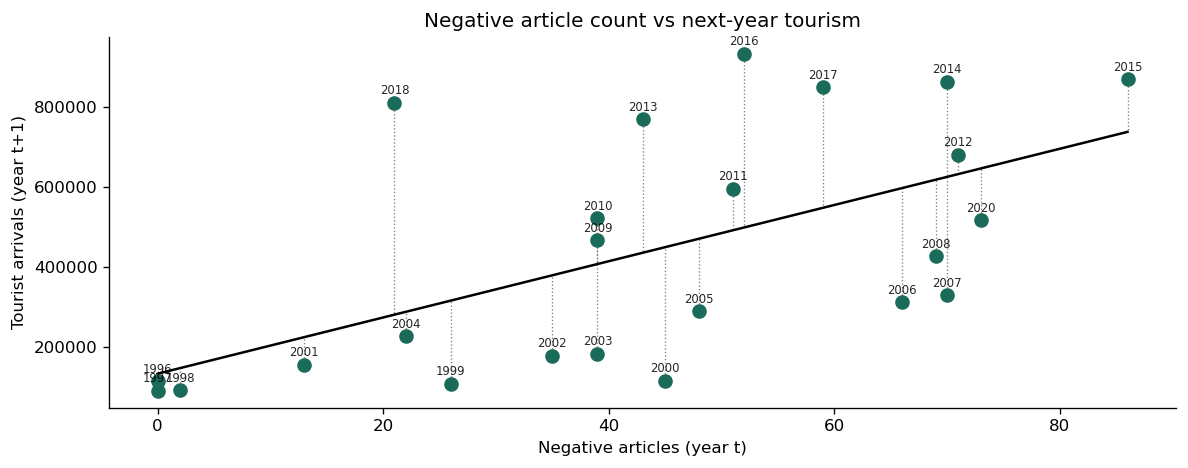

Slope m = 7029.2672  |  R² = 0.353  |  p-value = 0.0022
Direction: positive  |  statistically significant (p < 0.05)


{'slope': np.float64(7029.267192784668),
 'r_squared': np.float64(0.35274020751677715),
 'p_value': np.float64(0.0022140418445290326)}

In [12]:
regression_plot(
    x=df["negative_articles"],
    y=df["tourist_arrivals_next_year"],
    x_label="Negative articles (year t)",
    y_label="Tourist arrivals (year t+1)",
    title="Negative article count vs next-year tourism",
    year_labels=df["year"],
)


### Same year comparison (for reference only)

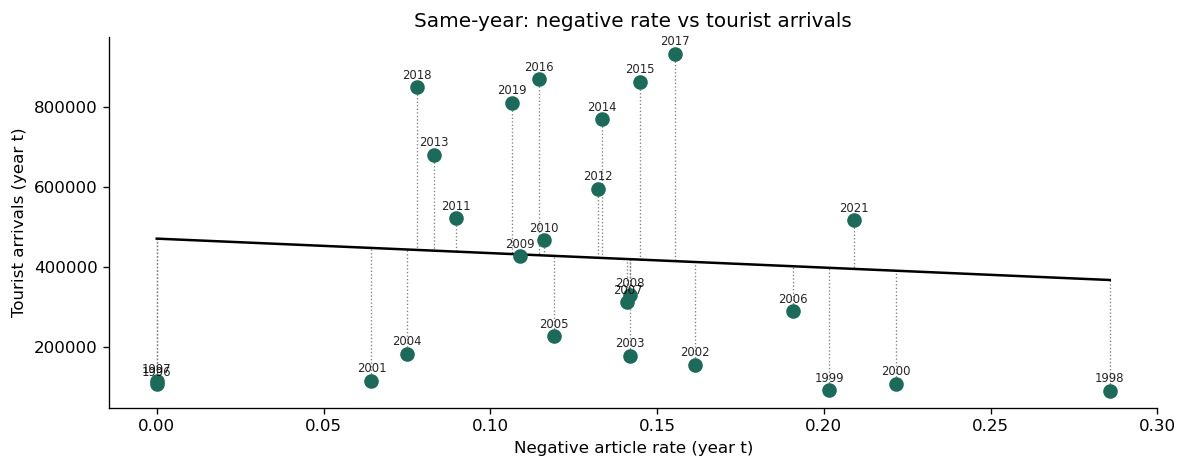

Slope m = -361979.8971  |  R² = 0.006  |  p-value = 0.7086
Direction: negative  |  NOT statistically significant (p >= 0.05)


{'slope': np.float64(-361979.8970919168),
 'r_squared': np.float64(0.006189183815966226),
 'p_value': np.float64(0.708554132278205)}

In [13]:
regression_plot(
    x=df["negative_rate"],
    y=df["tourist_arrivals"],
    x_label="Negative article rate (year t)",
    y_label="Tourist arrivals (year t)",
    title="Same-year: negative rate vs tourist arrivals",
    year_labels=df["year"],
)


### Q5 Findings

Based on the number of negative articles vs number of tourists, the result seems to be opposite of what you would expect. The slope is roughly 7029 which would indicate that for an increase of 1 negative artice there is an additional 7029 tourists visiting next year. But one point we have to consider is years with more negative coverage also tend to be years with more total coverage overall (as seen in Q4), and more coverage of any kind correlates with more tourism so it could be confounding the result. 
So to check even further see the negative rate vs number of tourists graph, where negative rate is the number of negatively written articles divided by the total number of articles that year. As you can see, the slope of that graph is negative meaning the more the share of negative articles increases the lessor the number of visitors next year. But the p value is well over 0.05, meaning the relationship is not statistically significant enough.

In short: **negative coverage alone does not appear to deter tourism** in this dataset, at least not in a way that is statistically separable from overall coverage volume.


---
## Q6. Does more positive coverage correspond to higher tourism the following year?

If positive coverage attracts tourists, we would expect a **positive slope**: higher positive rates in year *t* followed by more arrivals in year *t+1*.


### Positive rate (year t) vs tourist arrivals (year t+1)

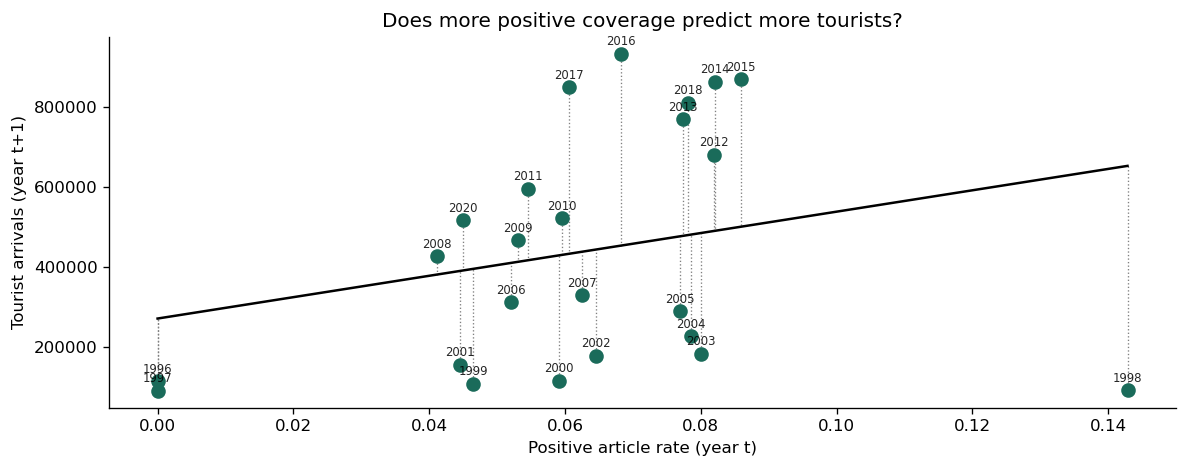

Slope m = 2671122.0104  |  R² = 0.066  |  p-value = 0.2251
Direction: positive  |  NOT statistically significant (p >= 0.05)


{'slope': np.float64(2671122.010354907),
 'r_squared': np.float64(0.06612488783976844),
 'p_value': np.float64(0.2251151416895384)}

In [14]:
regression_plot(
    x=df["positive_rate"],
    y=df["tourist_arrivals_next_year"],
    x_label="Positive article rate (year t)",
    y_label="Tourist arrivals (year t+1)",
    title="Does more positive coverage predict more tourists?",
    year_labels=df["year"],
)


### Positive article count (year t) vs tourist arrivals (year t+1)

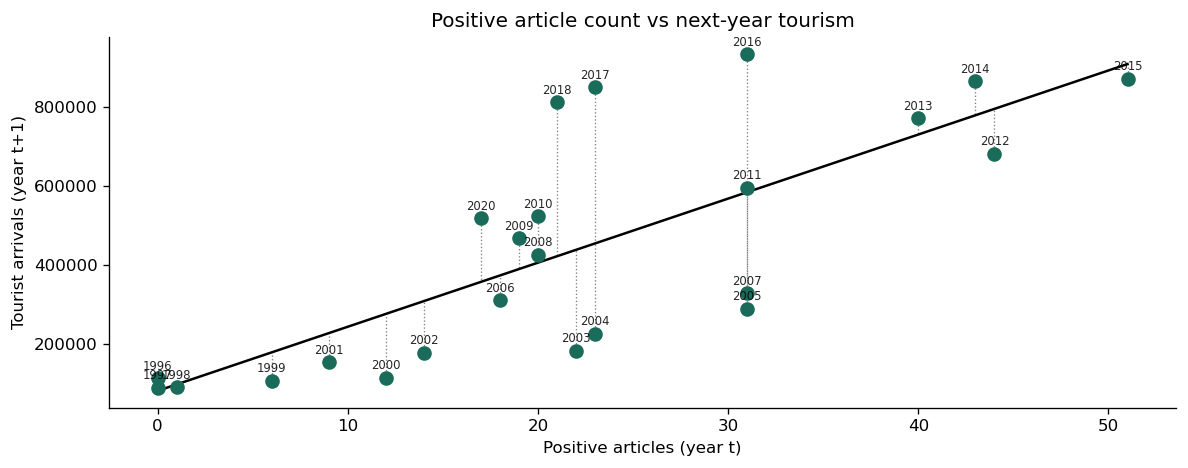

Slope m = 16167.6109  |  R² = 0.587  |  p-value = 0.0000
Direction: positive  |  statistically significant (p < 0.05)


{'slope': np.float64(16167.610921183774),
 'r_squared': np.float64(0.5866084381522363),
 'p_value': np.float64(1.2870840655620274e-05)}

In [15]:
regression_plot(
    x=df["positive_articles"],
    y=df["tourist_arrivals_next_year"],
    x_label="Positive articles (year t)",
    y_label="Tourist arrivals (year t+1)",
    title="Positive article count vs next-year tourism",
    year_labels=df["year"],
)


### Same-year comparison (for reference only)

In [ ]:
regression_plot(
    x=df["positive_rate"],
    y=df["tourist_arrivals"],
    x_label="Positive article rate (year t)",
    y_label="Tourist arrivals (year t)",
    title="Same-year: positive rate vs tourist arrivals",
    year_labels=df["year"],
)


### Q6 Findings

The positive rate shows a weak and generally non-significant association with number of tourists in the following year when we see the positive rate vs number of tourist arrival graph. But the number of positive article vs number of tourist arrival shows a more significant association with an increase of 1 positive article being correlated with an increase of roughly 16168 tourist arrivals , but again this is likely driven by the correlation between volume of coverage and tourism seen in Q4.

This suggests that **it is the volume of coverage rather than its positivity that is associated with higher tourism**, at least within the range and source of data available here.


---
## Final Conclusions

This project set out to answer whether Guardian media coverage of Ethiopia is associated with how many tourists the country receives. Here is a summary of what was found:

| Question | Finding |
|---|---|
| Q1: Has coverage grown? | Yes, significantly. Both total and focused articles mostly trend upward over 1996-2021. |
| Q2: Has sentiment changed? | No. Sentiment is mostly mildly and consistently negative throughout, with no significant trend. But when observing the number of articles, most of them are written in a neutral tone. |
| Q3: Which topics dominate? | Politics & Governance and Conflict & Security dominate, with Health & Development following. |
| Q4: Does coverage volume predict tourism? | More coverage correlates with more arrivals the following year, but we can't fully determine this due to the limitation of our dataset. |
| Q5: Does negative coverage deter tourism? | Not detectably. Negative rate alone does not show a significant negative effect based on our data. |
| Q6: Does positive coverage attract tourism? | Again not detectably beyond the effect of coverage volume overall. |

**The most important finding** is that overall coverage volume, regardless of sentiment, has the strongest correlation with next-year tourist arrivals in this dataset. This may reflect a simple awareness effect: the more Ethiopia appears in The Guardian, the more it is on the radar of potential visitors.

**But here are some limitations to keep in mind:**
- All results show association, not causation. Meaning we cannot conclude the Guardian's articles caused the tourism arrivals.
- Data is limited to one outlet (The Guardian), which is only one site and does not fully represent global media at all.
- Simple linear regression does not control for confounding variables such as economic conditions, regional stability, or global travel trends.
- Tourism data combines personal and business arrivals, which may respond differently to media coverage.

**Next steps** to take that would strengthen this analysis:
- Expand to multiple news sources across different countries and languages.
- Include additional variables (GDP, flight routes, regional conflict indicators) in a multivariate model.
- Use more precise sentiment labelling criteria in the GPT prompt.
- Separate leisure from business tourism in the arrivals data.

This is a starting point for a project I have wanted to pursue for a while. The association between coverage and tourism is real and worth exploring further with richer data. 

---
*Data: Guardian Open Platform API | Tourist arrivals: Kaggle / Mohamadreza Momeni*
*All regression results show association, not causation.*
